In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
FILE_PATH = 'data/data_317_01_100.h5' # Update this to your file's name
SEQ_LENGTH = 5                # How many past steps the LSTM looks at
BATCH_SIZE = 64
EPOCHS = 300
LEARNING_RATE = 0.001

In [3]:
X_COLUMNS = [
    'theta1', 'theta2', 'target_x', 'target_y', 'obstacle_x', 'obstacle_y',
    'ee_dist_to_target', 'ee_dist_to_obstacle', 'min_dist_obstacle_link_1',
    'min_dist_obstacle_link_2' 
    #, 'u1_prev', 'u2_prev' 
    #, 'ee_dx_target', 'ee_dy_target'
]
Y_COLUMNS = ['u1', 'u2']
# Hardcoded to CPU
device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
# ==========================================
# 2. Data Processing & Sequencing
# ==========================================
def create_sequences(features, targets, seq_length):
    """Slides a window across the data to create 3D sequence tensors."""
    xs, ys = [], []
    for i in range(len(features) - seq_length):
        x_window = features[i : i + seq_length]
        y_target = targets[i + seq_length] # Predict the target AT the current step
        xs.append(x_window)
        ys.append(y_target)
    return np.array(xs), np.array(ys)

In [5]:
# Load data (assuming it's saved as a standard pandas DataFrame in HDF5 format)
from load_data import load_data_from_file
data_dict = load_data_from_file(FILE_PATH)
# print(data_dict)

run_keys = list(data_dict.keys())
train_runs, test_runs = train_test_split(run_keys, test_size=0.2, random_state=42)

def extract_run(run_data):
    X = np.column_stack([run_data[col] for col in X_COLUMNS])
    Y = np.column_stack([run_data[col] for col in Y_COLUMNS])
    return X, Y

In [6]:
# Fit Scaler on Training Data Only
all_train_X = np.vstack([extract_run(data_dict[r])[0] for r in train_runs])
all_train_X

array([[ 0.52359878, -0.52359878,  1.68834742, ...,  3.09451952,
         1.8275144 ,  2.16965541],
       [ 0.5051547 , -0.53844534,  1.68834742, ...,  3.11857997,
         1.8275144 ,  2.18504236],
       [ 0.49031996, -0.55147558,  1.68834742, ...,  3.13776149,
         1.8275144 ,  2.19731587],
       ...,
       [ 1.26120416, -2.28187293,  0.79317262, ...,  2.02779595,
         1.22944333,  1.62545496],
       [ 1.26228198, -2.28357814,  0.79317262, ...,  2.02624282,
         1.22944333,  1.62464065],
       [ 1.26331145, -2.28520545,  0.79317262, ...,  2.02476005,
         1.22944333,  1.62386245]], shape=(8000, 10))

In [7]:
# Extract inputs and outputs
# X_raw = df[X_COLUMNS].values
# Y_raw = df[Y_COLUMNS].values
scaler_X = StandardScaler()
scaler_X.fit(all_train_X)

,copy,True
,with_mean,True
,with_std,True


In [8]:
def process_and_sequence_runs(run_list, scaler):
    X_seqs, Y_seqs = [], []
    for r in run_list:
        X_raw, Y_raw = extract_run(data_dict[r])
        X_scaled = scaler.transform(X_raw)
        
        # Slide window
        for i in range(len(X_scaled) - SEQ_LENGTH):
            X_seqs.append(X_scaled[i : i + SEQ_LENGTH])
            Y_seqs.append(Y_raw[i + SEQ_LENGTH])
            
    return np.array(X_seqs), np.array(Y_seqs)

X_train_seq, Y_train_seq = process_and_sequence_runs(train_runs, scaler_X)
X_test_seq, Y_test_seq = process_and_sequence_runs(test_runs, scaler_X)

# Create DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32), 
                              torch.tensor(Y_train_seq, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32), 
                             torch.tensor(Y_test_seq, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
# ==========================================
# 3. Model Definition
# ==========================================
class CollisionAvoidanceLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # dropout only applies between LSTM layers, so only useful if num_layers > 1
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.dropout = nn.Dropout(dropout)  # apply after LSTM output
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc1(out)
        out = self.relu(out)
        return self.fc2(out)

In [13]:
# Create lists to store both sets of losses
train_losses = []
test_losses = []
model = CollisionAvoidanceLSTM(
    input_size=10,
    hidden_size=32,   # try 32 or 64 instead of whatever you have now
    num_layers=1,     # start with 1
    output_size=2,
    dropout=0.3
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
print("\nStarting Training & Testing on CPU...")
for epoch in range(EPOCHS):
    
    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train() # Tell PyTorch we are actively learning
    running_train_loss = 0.0
    
    for batch_X, batch_Y in train_loader:
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_Y)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ==========================
    #      TESTING PHASE
    # ==========================
    model.eval() # Tell PyTorch to freeze dropout/batchnorm layers
    running_test_loss = 0.0
    
    # torch.no_grad() turns off the memory-heavy gradient calculations
    # since we don't backpropagate during testing!
    with torch.no_grad():
        for batch_X, batch_Y in test_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            running_test_loss += loss.item()
            
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # ==========================
    #        LOGGING
    # ==========================
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("Training & Testing Finished!")


Starting Training & Testing on CPU...
Epoch [5/300] | Train Loss: 0.003593 | Test Loss: 0.002641
Epoch [10/300] | Train Loss: 0.002553 | Test Loss: 0.003014
Epoch [15/300] | Train Loss: 0.002165 | Test Loss: 0.002806
Epoch [20/300] | Train Loss: 0.002078 | Test Loss: 0.002619
Epoch [25/300] | Train Loss: 0.002087 | Test Loss: 0.002621
Epoch [30/300] | Train Loss: 0.001951 | Test Loss: 0.002908
Epoch [35/300] | Train Loss: 0.001912 | Test Loss: 0.003047
Epoch [40/300] | Train Loss: 0.001754 | Test Loss: 0.002862
Epoch [45/300] | Train Loss: 0.001820 | Test Loss: 0.002953
Epoch [50/300] | Train Loss: 0.001649 | Test Loss: 0.003114
Epoch [55/300] | Train Loss: 0.001746 | Test Loss: 0.003193
Epoch [60/300] | Train Loss: 0.001697 | Test Loss: 0.003211
Epoch [65/300] | Train Loss: 0.001678 | Test Loss: 0.003043
Epoch [70/300] | Train Loss: 0.001591 | Test Loss: 0.003068
Epoch [75/300] | Train Loss: 0.001616 | Test Loss: 0.003626
Epoch [80/300] | Train Loss: 0.001647 | Test Loss: 0.003387
Ep

In [14]:
print(Y_train_seq.mean(axis=0), Y_train_seq.std(axis=0))

[ 0.10186213 -0.07607724] [0.15226669 0.20516514]


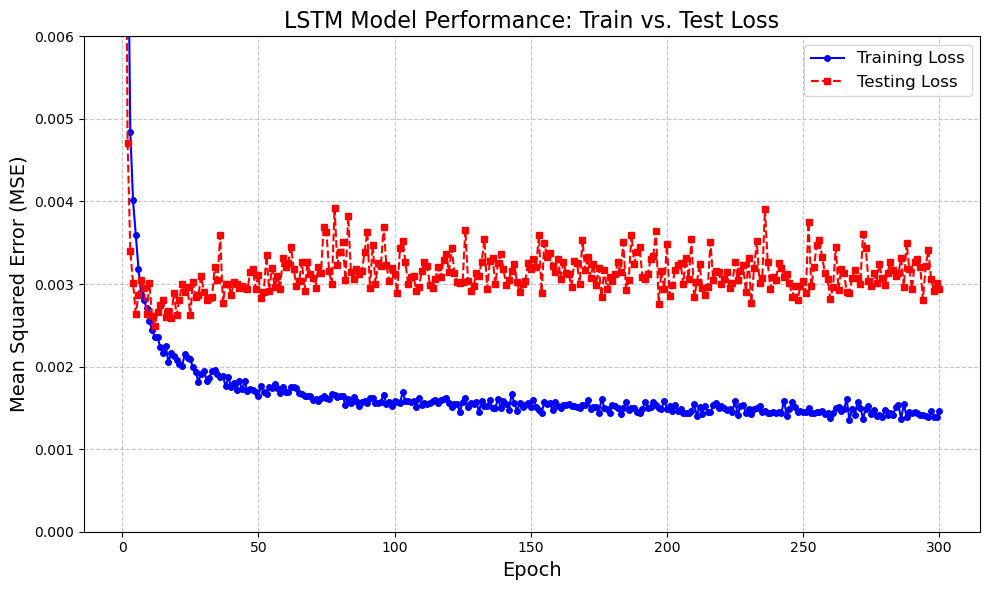

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot both lines
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', markersize=4, linestyle='-', color='blue', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), test_losses, marker='s', markersize=4, linestyle='--', color='red', label='Testing Loss')

# Add labels and title
plt.title('LSTM Model Performance: Train vs. Test Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.ylim(0, 0.006)
# Aesthetics
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

# Render the graph
plt.show()